# Lab 6 : Image Segmentation

#Image Segmentation Using TensorFlow

In this notebook we will do image segmentation on the dataset "Oxford-3T Pet Dataset".
Dataset consists of **37** pet breeds with 200 images per breed.

Each image includes the correspondig labels and pixelwise masks. The masks are class-labels for each pixel and each pixel is given one of three categories:

    *  Class 1: Pixel belonging to pet
    *  Class 2: Pixel bordering the pet
    *  Class 3: None(surroundin pixel)

In [45]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Image Segmentation/'

Mounted at /content/drive


##Check for Graphic Card

In [2]:
!nvidia-smi

Thu May 29 09:28:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##Getting the Helper Function

In [3]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2025-05-29 09:28:20--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-05-29 09:28:20 (71.1 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [4]:
from helper_functions import *

##Downloading the Oxford-3T Pets dataset

In [5]:
#importing the libraries
import tensorflow as tf
import tensorflow_datasets as tfds

In [6]:
#tfds.list_builders()

In [15]:
#download the dataset
(train_data, test_data), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True  # Optional, returns (image, label) pairs
)

##Preprocessing of Data

In [16]:
train_data, test_data

(<_PrefetchDataset element_spec={'file_name': TensorSpec(shape=(), dtype=tf.string, name=None), 'head_bbox': TensorSpec(shape=(4,), dtype=tf.float32, name=None), 'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'segmentation_mask': TensorSpec(shape=(None, None, 1), dtype=tf.uint8, name=None), 'species': TensorSpec(shape=(), dtype=tf.int64, name=None)}>,
 <_PrefetchDataset element_spec={'file_name': TensorSpec(shape=(), dtype=tf.string, name=None), 'head_bbox': TensorSpec(shape=(4,), dtype=tf.float32, name=None), 'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'segmentation_mask': TensorSpec(shape=(None, None, 1), dtype=tf.uint8, name=None), 'species': TensorSpec(shape=(), dtype=tf.int64, name=None)}>)

In [17]:
#infor
ds_info

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLab

###Normalization & Loading

In [18]:
#function for normalization
def normalize(input_image, input_mask):
  input_image = tf.cast(input_image, tf.float32)/255.
  input_mask -= 1
  return input_image, input_mask


In [19]:
#loadimages
def load_image(datapoint):
  input_image = tf.image.resize(datapoint['image'], (224, 224))
  input_mask  = tf.image.resize(datapoint['segmentation_mask'], (224,224))

  input_image, input_mask = normalize(input_image,
                                      input_mask)
  return input_image, input_mask

In [20]:
#trainlen and batch size
TRAIN_LENGTH = ds_info.splits['train'].num_examples
BATCH_SIZE = 32
BUFFER_SIZE = 1000


In [21]:
TRAIN_LENGTH

3680

In [22]:
train_data = train_data.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

In [23]:
train_data, test_data

(<_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(224, 224, 1), dtype=tf.float32, name=None))>,
 <_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(224, 224, 1), dtype=tf.float32, name=None))>)

###Data Augmentation

In [27]:
import tensorflow as tf
from tensorflow.keras.layers import RandomFlip

class Augment(tf.keras.layers.Layer):
    def __init__(self, seed=54):
        super().__init__()
        self.augment_inputs = RandomFlip(mode="horizontal", seed=seed)
        self.augment_labels = RandomFlip(mode="horizontal", seed=seed)

    def call(self, inputs, labels):
        inputs = self.augment_inputs(inputs)
        labels = self.augment_labels(labels)
        return inputs, labels

In [28]:
#build the input pipeline
train_batches = (
    train_data
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE)
                 )

test_batches= test_data.batch(BATCH_SIZE)

##Visualize the data

In [29]:
import matplotlib.pyplot as plt
def display(display_list):
  plt.figure(figsize=(15,15))

  title=['Input_Image', 'True_Mask', 'Predicted_Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

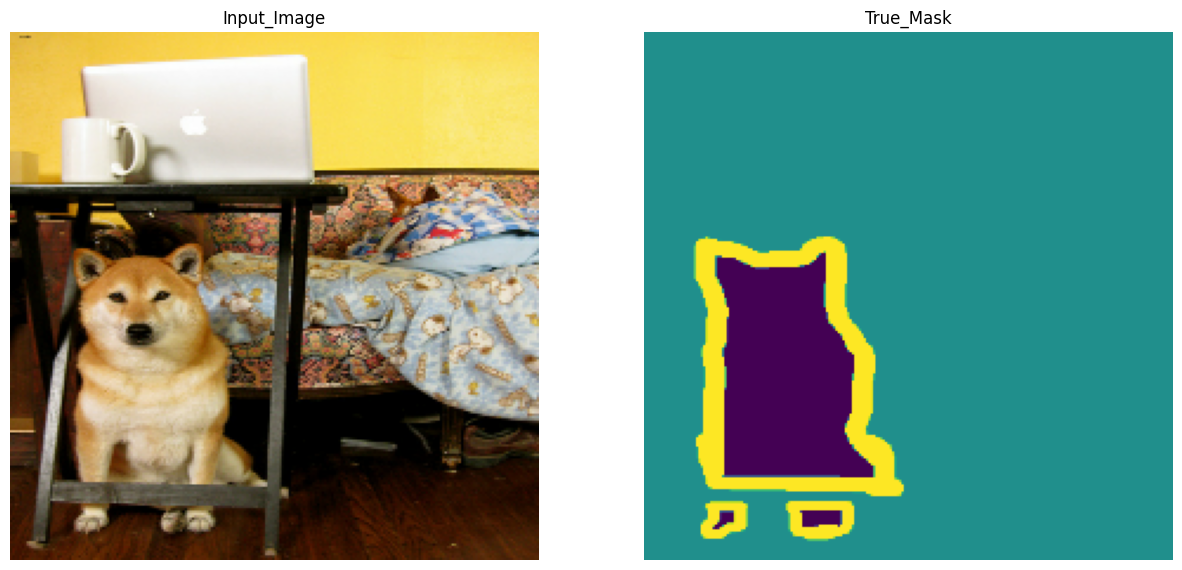

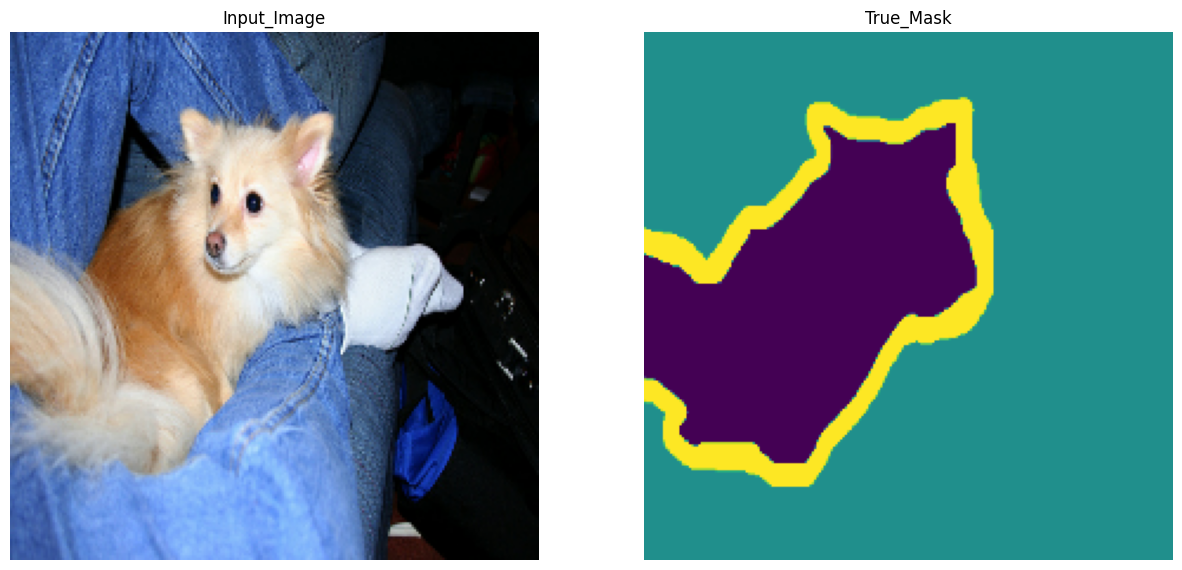

In [30]:
for images, masks in train_batches.take(2):
  sample_image, sample_mask = images[1], masks[1]
  display ([sample_image, sample_mask])

##Defining the Model

In [31]:
base_model = tf.keras.applications.MobileNetV2(include_top=False,
                                               input_shape=[224,224,3])

layer_names = [
               'block_1_expand_relu',
               'block_3_expand_relu',
               'block_6_expand_relu',
               'block_13_expand_relu',
               'block_16_project'
]

base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

#Feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)

down_stack.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [32]:
#Decoder/upsampler
!pip install git+https://github.com/tensorflow/examples.git
from tensorflow_examples.models.pix2pix import pix2pix
up_stack =[
           pix2pix.upsample(512, 3),
           pix2pix.upsample(256, 3),
           pix2pix.upsample(128, 3),
           pix2pix.upsample(64, 3)
]

  Cloning https://github.com/tensorflow/examples.git to /tmp/pip-req-build-ke9fi0bw
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/examples.git /tmp/pip-req-build-ke9fi0bw
  Resolved https://github.com/tensorflow/examples.git to commit 3c7435733a9162481df350e57c53e58d2a705e4d
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-examples: filename=tensorflow_examples-0.1746868094.345130988853936603129253091149118257392589495885-py3-none-any.whl size=301646 sha256=59ae7784629382c0721b3017dea7bc9d0b14574fa0fc6560a539c2cbff46fa58
  Stored in directory: /tmp/pip-ephem-wheel-cache-jz1_oqq1/wheels/91/9b/e8/6ae2ecc930bd726c578e35b313e987a687bc5ce03c3a42c2d5
Successfully built tensorflow-examples


In [33]:
#unet_model
def unet_model(output_channels:int):
  inputs = tf.keras.layers.Input(shape=[224,224,3])
  #downsampling
  skips = down_stack(inputs)
  x = skips[-1]
  skips = reversed(skips[:-1])

  #upsampling
  for up, skip in zip(up_stack, skips):
    x = up(x)
    concat = tf.keras.layers.Concatenate()
    x = concat([x, skip])

  #last layer of model
  last = tf.keras.layers.Conv2DTranspose(
      filters = output_channels, kernel_size=3, strides=2,
      padding='same'
  )
  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)


##Train the model

In [34]:
output_classes=3
model = unet_model(output_channels=output_classes)
model.compile(loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

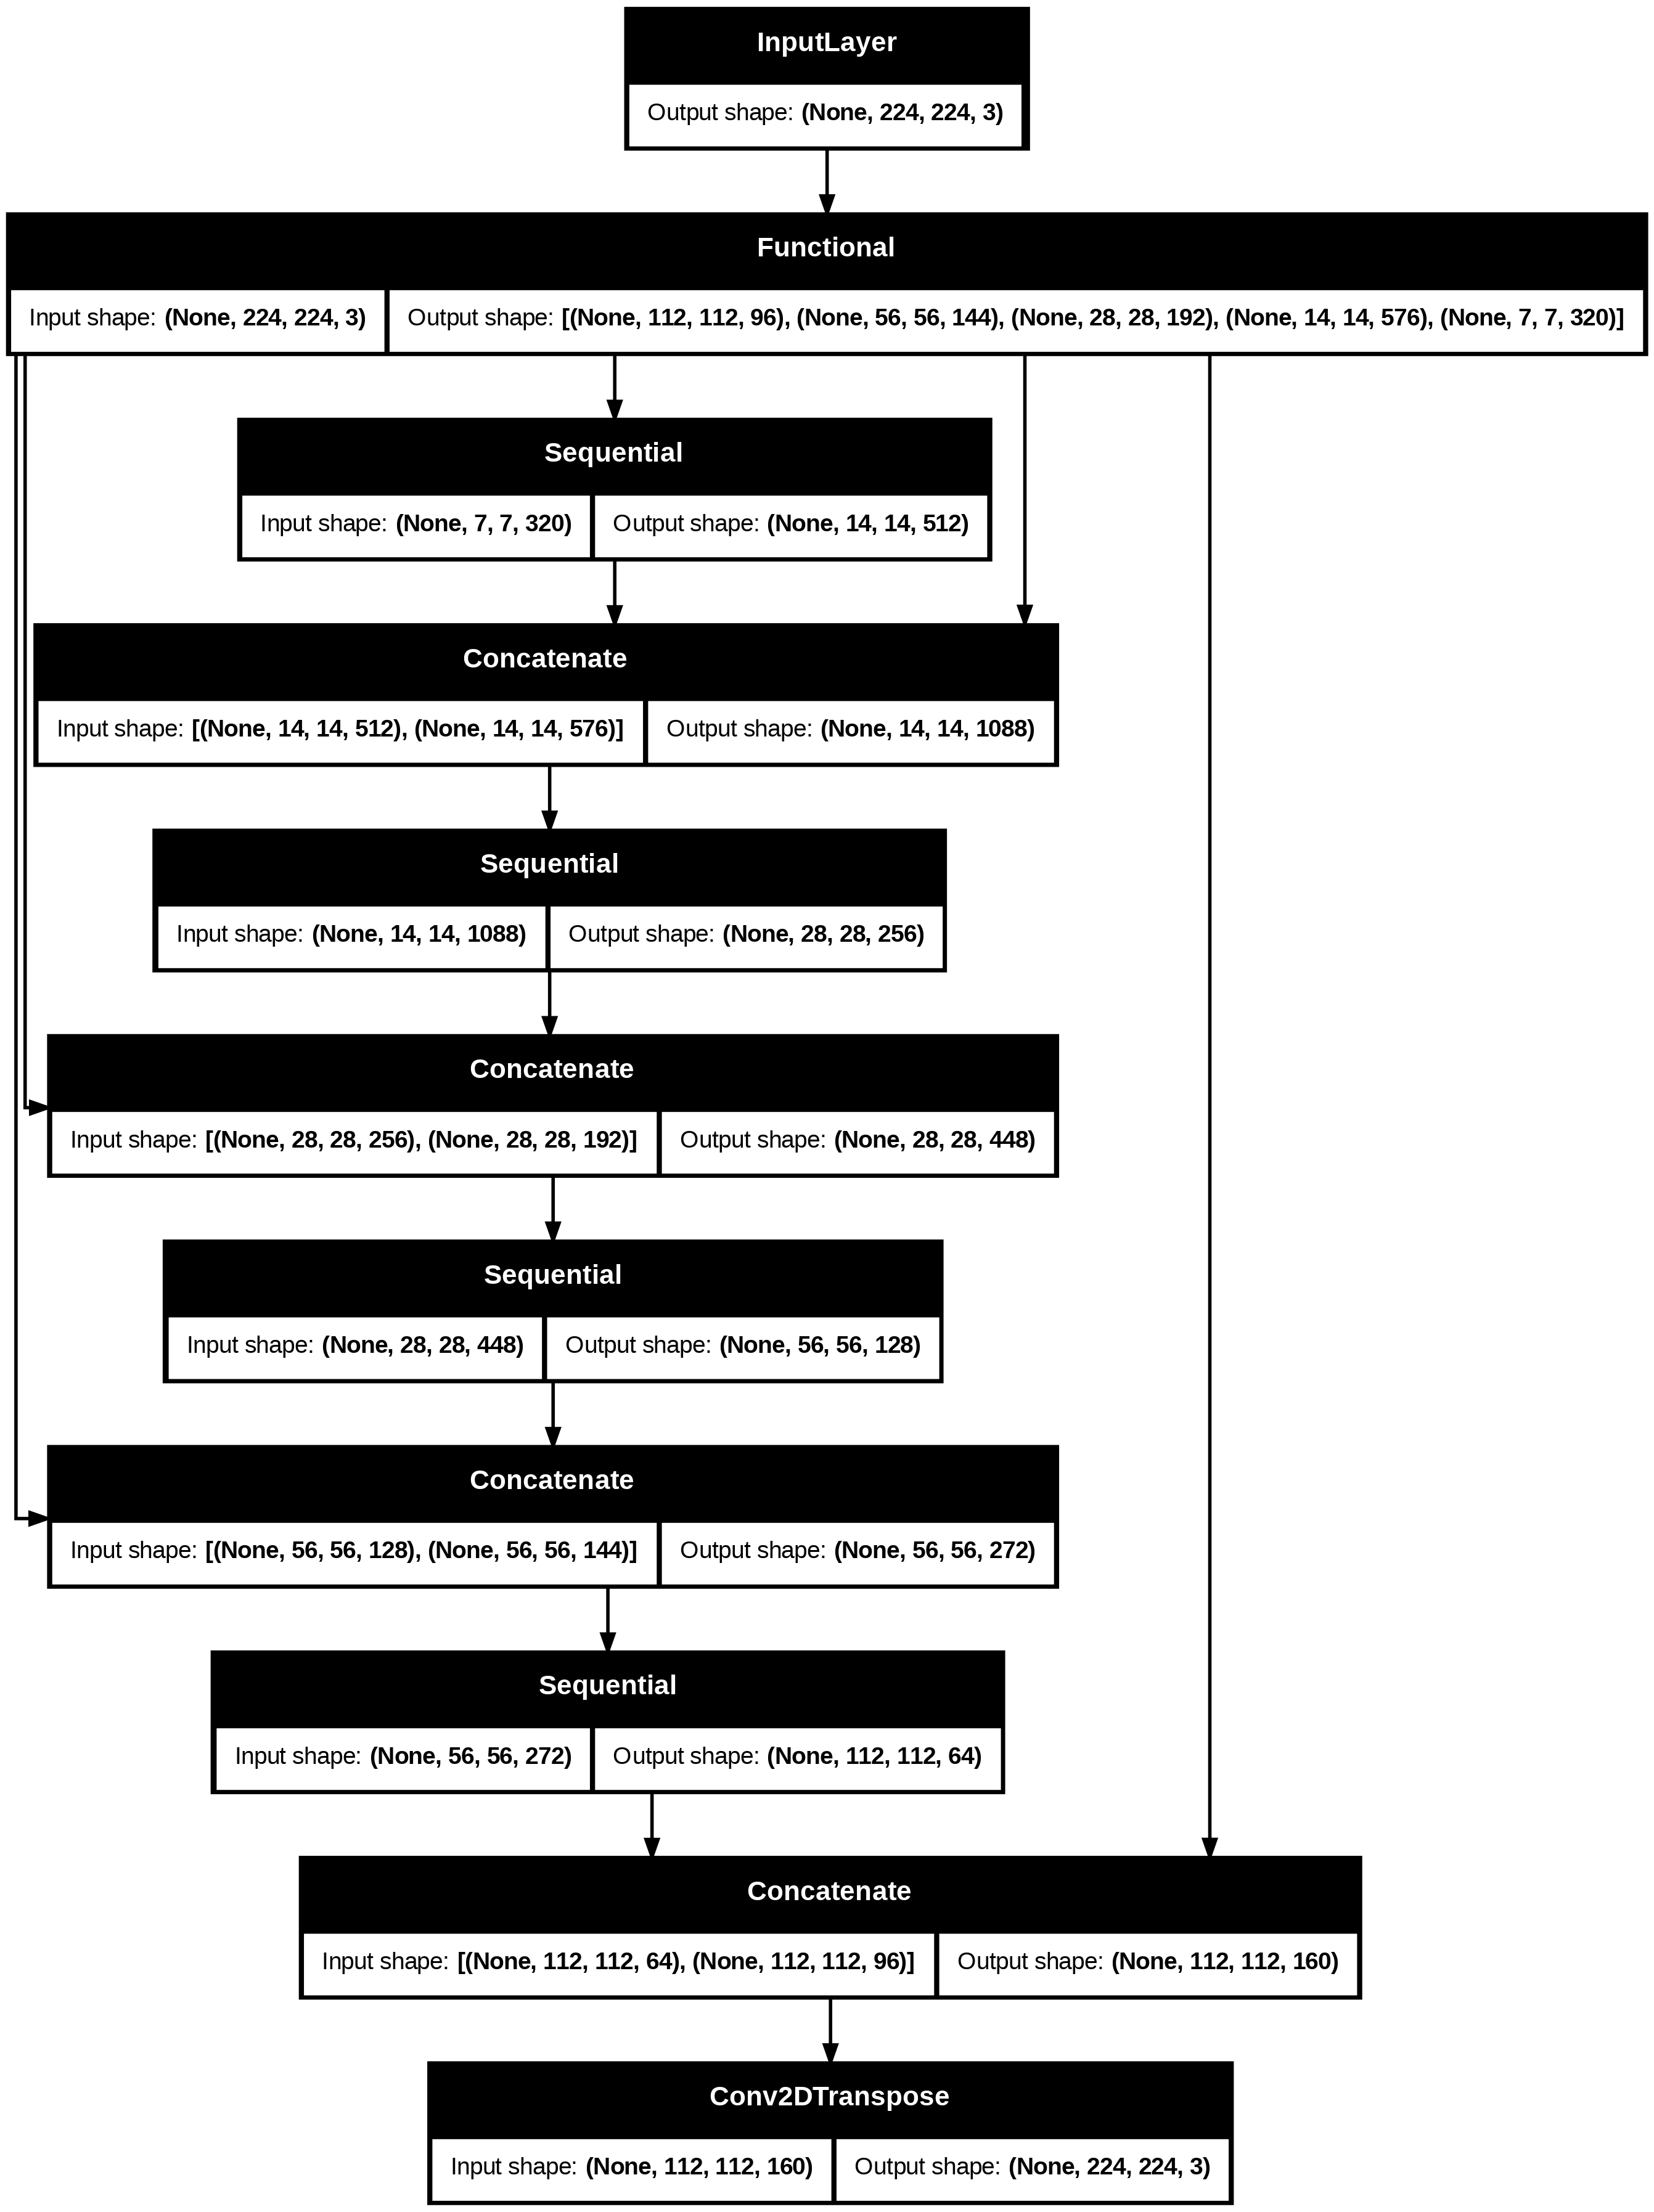

In [35]:
# show the model
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

In [36]:
#fuctions for predictions
def create_mask(pred_mask):
  pred_mask = tf.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

In [37]:
def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


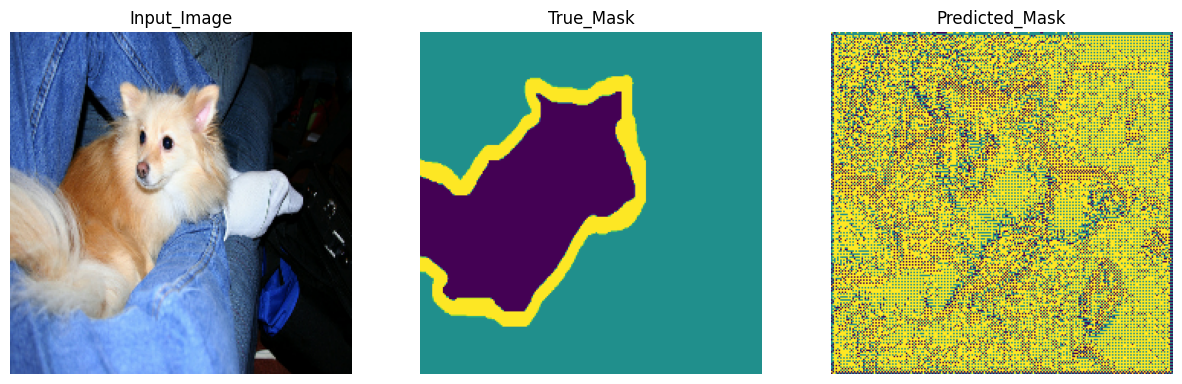

In [38]:
#predictions before training
show_predictions()

In [39]:
#Call back
from IPython.display import clear_output
class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_prediction()
    print('\nsample Prediction after epoch {}\n'.format(epoch+1))

In [40]:
model_history = model.fit(train_batches,
                          epochs=10,
                          validation_data= test_batches,
                          validation_steps=int(0.15 * len(test_batches)),
                          steps_per_epoch=115,
                          )

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 53s 240ms/step - accuracy: 0.7584 - loss: 0.5834 - val_accuracy: 0.8483 - val_loss: 0.3913
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 339ms/step - accuracy: 0.8906 - loss: 0.2677 - val_accuracy: 0.8926 - val_loss: 0.2721
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - accuracy: 0.8963 - loss: 0.2493 - val_accuracy: 0.8998 - val_loss: 0.2509
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 175ms/step - accuracy: 0.8970 - loss: 0.2468 - val_accuracy: 0.9008 - val_loss: 0.2470
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - accuracy: 0.9012 - loss: 0.2351 - val_accuracy: 0.9007 - val_loss: 0.2437
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 165ms/step - accuracy: 0.9039 - loss: 0.2273 - val_accuracy: 0.9029 - val_loss: 0.2385
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 181ms/step - accuracy: 0.9039 - loss: 0.2271 - val_accuracy: 0.9022 - val_loss: 0.2405
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - accuracy: 0.9059 - loss: 0

In [41]:
results=model.evaluate(test_batches)

115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.9076 - loss: 0.2267


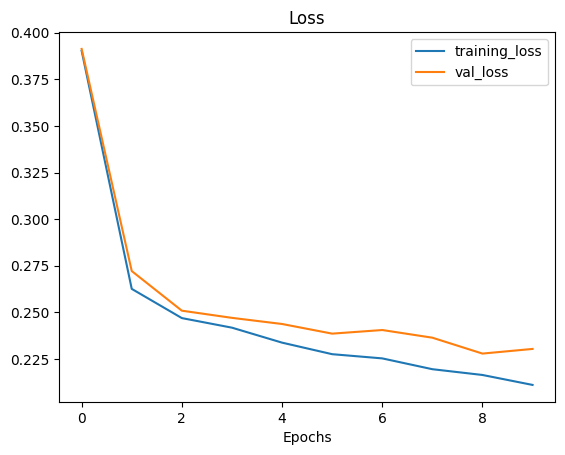

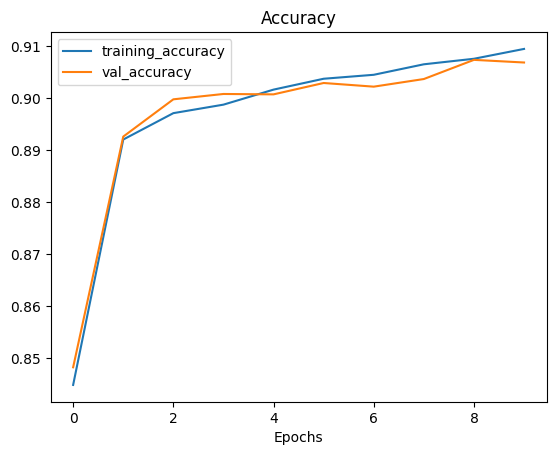

In [42]:
plot_loss_curves(model_history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


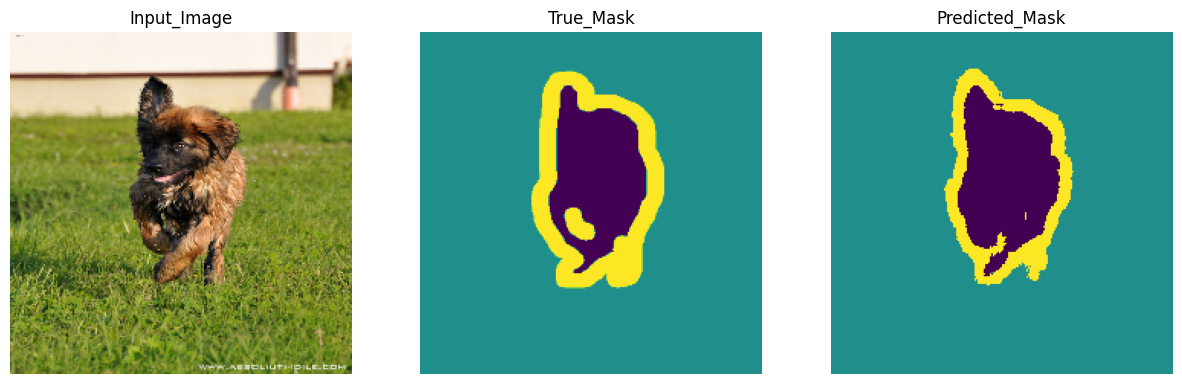

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


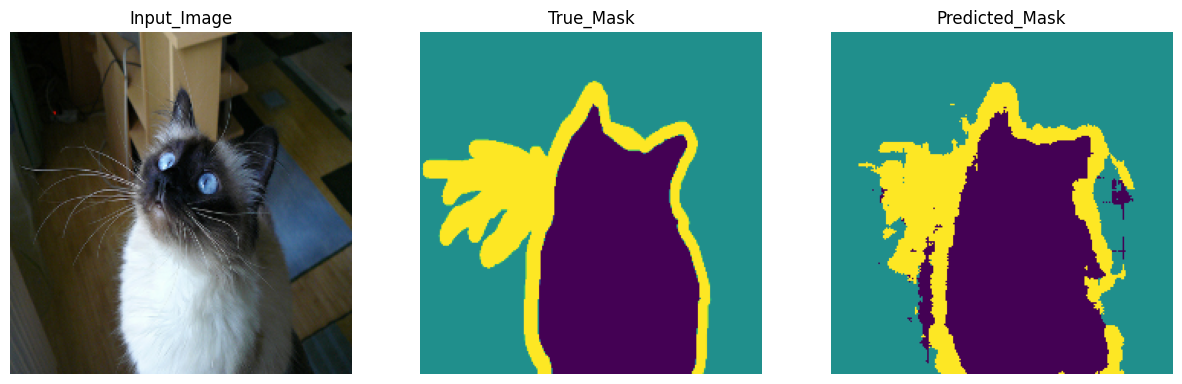

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


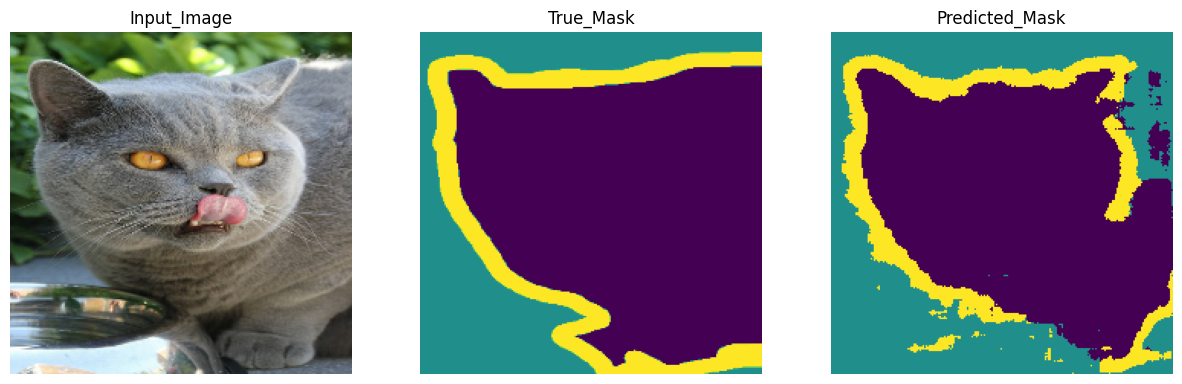

In [43]:
show_predictions(test_batches, 3)

Test your Model now on any random Cat and Dog Image from the Internet !!!!!! Let's see how good our predictions can be :)

array([[[186, 189, 196],
        [168, 171, 178],
        [168, 171, 178],
        ...,
        [215, 219, 220],
        [215, 219, 220],
        [215, 219, 220]],

       [[186, 189, 196],
        [168, 171, 178],
        [168, 171, 178],
        ...,
        [215, 219, 220],
        [215, 219, 220],
        [216, 220, 221]],

       [[186, 189, 196],
        [169, 172, 179],
        [169, 172, 179],
        ...,
        [216, 220, 221],
        [216, 220, 221],
        [216, 220, 221]],

       ...,

       [[193, 195, 181],
        [175, 178, 161],
        [175, 178, 159],
        ...,
        [166, 165, 134],
        [167, 166, 135],
        [167, 166, 135]],

       [[194, 197, 180],
        [176, 179, 162],
        [176, 179, 160],
        ...,
        [168, 169, 138],
        [168, 169, 138],
        [169, 170, 139]],

       [[194, 197, 180],
        [177, 180, 161],
        [176, 179, 160],
        ...,
        [175, 178, 147],
        [176, 179, 148],
        [176, 179, 148]]], dtype=uint8)
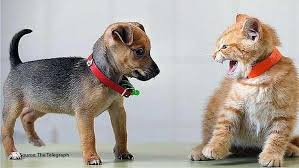

In [46]:
img = plt.imread("/content/drive/MyDrive/Image Segmentation/cat_dog.jpg")
plt.imread("/content/drive/MyDrive/Image Segmentation/cat_dog.jpg")

In [47]:
img=tf.image.resize(img, (224,224))
img= tf.cast(img, tf.float32)
img=img/255.
img.shape

TensorShape([224, 224, 3])

In [48]:
def pred(img):
  pred_mask=model.predict(tf.expand_dims(img, axis=0))
  display([img,  create_mask(pred_mask)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


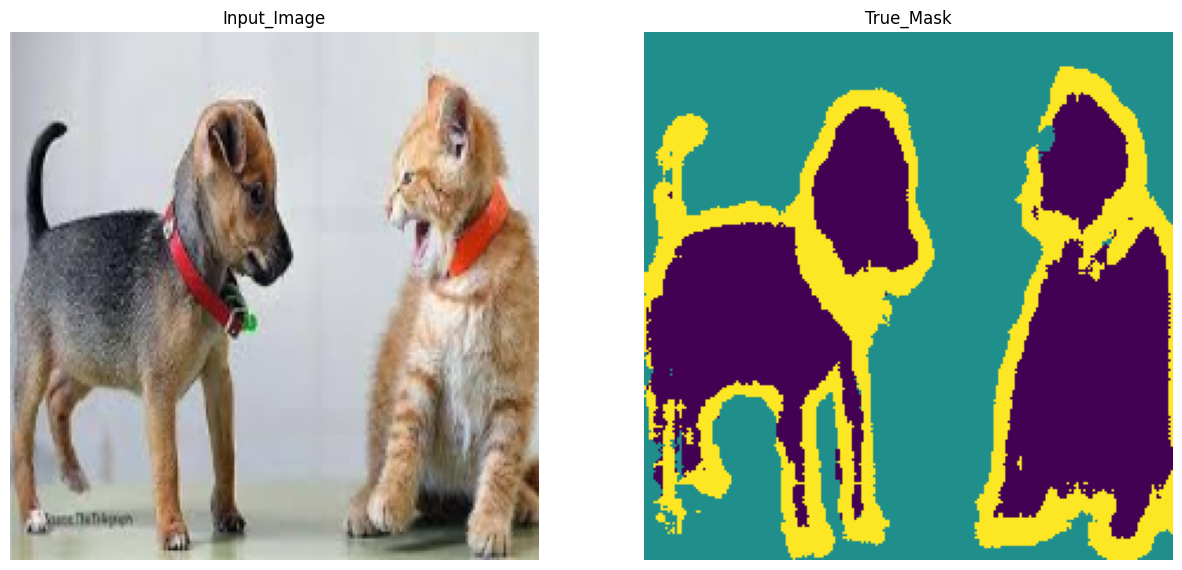

In [49]:
pred(img)